# E29 · Bayesian neural networks: what the posterior over weights buys you

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | The motorcycle-crash accelerometer readings of E05 (Silverman 1985, 133 readings) and 1030 laboratory concrete cylinders with their mix, age and compressive strength (Yeh 1998), a standard BNN benchmark |
| **You will learn** | A multilayer perceptron in plain PyMC with `dims` · priors over weights *are* priors over functions: width, $1/\sqrt{H}$ scaling and Neal's GP limit, and why $N(0, 1)$ on every weight is absurd · NUTS on a network, honestly: divergences, tree depth, what non-centring does and does not fix · why $\hat R$ on weights is meaningless and how to diagnose in **function space** · NUTS vs mean-field and full-rank ADVI vs Pathfinder vs a deep-ensemble of MAP fits vs a last-layer Laplace, scored on held-out data · BNN vs the heteroskedastic GP of E05 inside and outside the data · held-out elpd, interval coverage and PIT histograms · a BNN with ARD against GLM baselines on a tabular task, including extrapolation to older concrete · when a BNN is worth it |

E11 put a small network inside an ODE and found that its weights, read one at a time,
teach you nothing: a network's posterior is only interpretable through the *functions* it
implies. E12 raced samplers and variational approximations on a hard but ordinary
posterior. This notebook puts both lessons to work on the model class where they bite
hardest - a plain feed-forward network used as a flexible regression function - and asks
the practical question: **what does the posterior over weights buy you** that a point
estimate, a cheap approximation, a Gaussian process or a GLM does not?

Two data sets. The motorcycle crash of E05 is one-dimensional, so every claim can be
*looked at*, and E05's heteroskedastic GP is a ready-made opponent. The concrete data have
eight inputs and the kind of interactions that GLMs miss, which is where a network ought
to earn its keep.

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pymc_extras as pmx
import pytensor.tensor as pt
import xarray as xr
from pymc.model.transform.optimization import freeze_dims_and_data
from scipy import stats
from scipy.special import logsumexp

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c93c3c"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def rhat_ess(array):
    """Worst r_hat and smallest bulk ESS over the trailing dimensions of a (chain, draw, ...) array."""
    dims = ["chain", "draw", *[f"d{i}" for i in range(array.ndim - 2)]]
    ds = xr.Dataset({"q": (dims, array)})
    return float(az.rhat(ds)["q"].max()), float(az.ess(ds)["q"].min())

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The motorcycle data, split once

E05 introduced the data: head acceleration of a crash-test dummy after a simulated
motorcycle impact, flat, then a plunge to about -130 g, a rebound and a noisy tail, with
scatter that changes by an order of magnitude along the way. As there, acceleration is
divided by its standard deviation but not centred, so 0 means "no acceleration". Time is
standardised for the network (inputs of order one keep the weight priors readable).

To score predictions honestly we hold out a random quarter of the readings - 33 of 133 -
and never let any method see them. Thirty-three points make a noisy test, so every
comparison below comes with a standard error.

mcycle: Head acceleration (g) against time after impact (ms), 133 readings.
  source: Silverman (1985), simulated motorcycle crash experiment, via R package `MASS`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/MASS/mcycle.csv
100 training and 33 test readings; 1 unit of y = 48.3 g, 1 unit of x = 13.1 ms


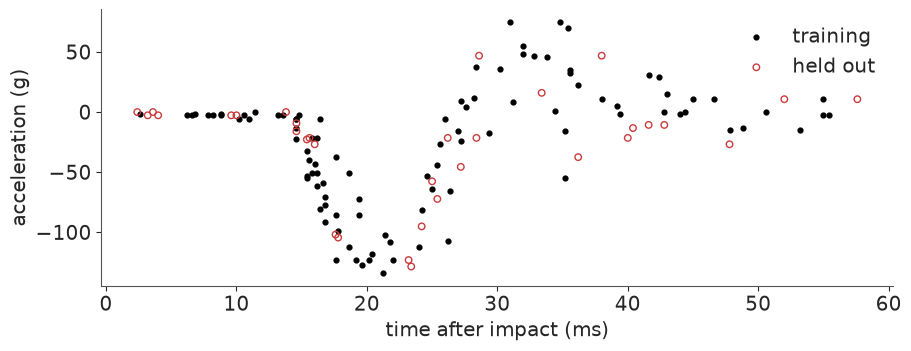

In [2]:
data.describe("mcycle")
mcycle = data.load("mcycle")
t = mcycle.times.to_numpy()
ACCEL_SD = mcycle.accel.std()
y = mcycle.accel.to_numpy() / ACCEL_SD
T_MU, T_SD = t.mean(), t.std()
x = (t - T_MU) / T_SD

perm = rng.permutation(len(t))
test, train = np.sort(perm[:33]), np.sort(perm[33:])
t_grid = np.linspace(-5, 70, 200)  # past both ends of the record (2.4 - 57.6 ms)
x_grid = (t_grid - T_MU) / T_SD
print(f"{len(train)} training and {len(test)} test readings; 1 unit of y = {ACCEL_SD:.1f} g, "
      f"1 unit of x = {T_SD:.1f} ms")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.scatter(t[train], y[train] * ACCEL_SD, s=12, color="k", label="training")
ax.scatter(t[test], y[test] * ACCEL_SD, s=22, facecolor="none", edgecolor=RED, label="held out")
ax.set(xlabel="time after impact (ms)", ylabel="acceleration (g)")
ax.legend();

## 2 · A network is three lines of PyTensor

One hidden layer of $H$ tanh units, with **two heads** that share it: one for the mean
curve $f(t)$ and one for the log noise sd, because E05 showed that a single $\sigma$ is
wrong for these data:

$$
h_j(x) = \tanh(W_j x + b_j), \qquad f(x) = \sum_j w^f_j h_j(x) + b^f, \qquad
\log\sigma(x) = \sum_j w^\sigma_j h_j(x) + b^\sigma, \qquad y \sim N\big(f(x), \sigma(x)\big).
$$

In PyMC the weights are ordinary random variables with a `hidden` dimension, and the
forward pass is `pt.tanh(x[:, None] * W1 + b1) @ wf`. We will want the *same* forward pass
in NumPy many times (prior draws, predictions on a grid, every approximation), so it is
written once for arrays of draws:

In [3]:
H = 16
WEIGHTS = ["W1", "b1", "wf", "bf", "ws", "bs"]


def forward(w, xs):
    """w: dict of arrays with a leading draw axis. Returns f and log sigma, shape (draws, len(xs))."""
    h = np.tanh(xs[None, :, None] * w["W1"][:, None, :] + w["b1"][:, None, :])
    f = np.einsum("sgh,sh->sg", h, w["wf"]) + w["bf"][:, None]
    log_s = np.einsum("sgh,sh->sg", h, w["ws"]) + w["bs"][:, None]
    return f, log_s


def weight_draws(idata):
    """Posterior draws of the network weights, chains stacked."""
    post = idata.posterior
    return {k: post[k].to_numpy().reshape(-1, *post[k].shape[2:]) for k in WEIGHTS}

## 3 · Priors over weights are priors over functions

Nobody has a prior belief about `W1[7]`. What we do have beliefs about is the curve: it
should vary on the scale of the data (a few units of $y$), wiggle on a timescale of a few
milliseconds or more, and not do anything absurd between readings. So we choose weight
priors by drawing *functions* from them. Three knobs matter, and NumPy is enough to see
all three.

**Knob 1: the width $H$ and the scale of the output weights.** With $N(0, 1)$ on every
weight, $f(x)$ is a sum of $H$ independent bounded terms, so its prior sd grows like
$\sqrt{H}$: a 512-unit network "expects" accelerations twenty times larger than anything
in the data. Neal (1996) showed the fix and its consequence. Give the output weights sd
$\sigma_w/\sqrt{H}$ and the prior variance of $f$ no longer depends on $H$; and as
$H \to \infty$ the central limit theorem makes $f$ a **Gaussian process**, whose kernel is set
by the input-weight prior and the activation.

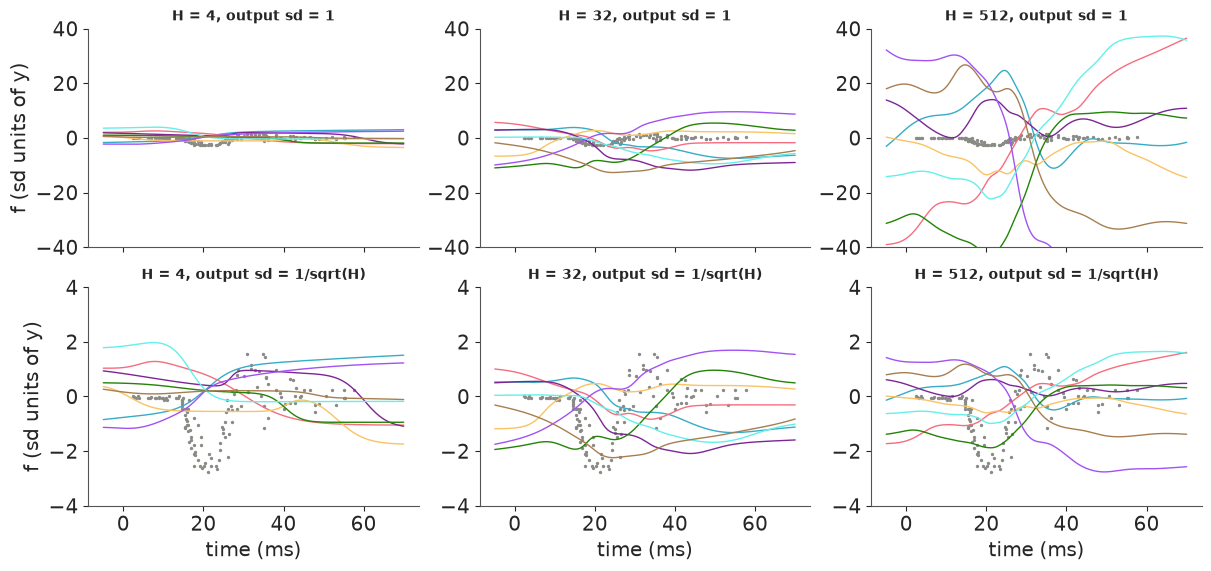

In [4]:
def prior_functions(n, width, w_in=3.0, scaled=True, seed=0, xs=x_grid):
    r = np.random.default_rng(seed)
    w = {"W1": w_in * r.normal(size=(n, width)), "b1": w_in * r.normal(size=(n, width)),
         "wf": r.normal(size=(n, width)) / (np.sqrt(width) if scaled else 1.0),
         "bf": np.zeros(n), "ws": np.zeros((n, width)), "bs": np.zeros(n)}
    return forward(w, xs)[0]


widths = [4, 32, 512]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.6), sharex=True)
for col, width in enumerate(widths):
    for row, scaled in enumerate([False, True]):
        ax = axes[row, col]
        ax.plot(t_grid, prior_functions(8, width, scaled=scaled, seed=col).T, lw=1)
        ax.scatter(t, y, s=2, color=GREY)
        ax.set_title(f"H = {width}, output sd = {'1/sqrt(H)' if scaled else '1'}", fontsize=10)
    axes[0, col].set_ylim(-40, 40)
    axes[1, col].set_ylim(-4, 4)
axes[0, 0].set_ylabel("f (sd units of y)")
axes[1, 0].set_ylabel("f (sd units of y)")
for ax in axes[1]:
    ax.set_xlabel("time (ms)");

Top row: the naive prior. Note the y axis runs to $\pm 40$: the grey dots, the data, are a
thin line in the middle. At $H = 512$ the prior puts almost no mass on functions of the
data's size. Bottom row: the $1/\sqrt{H}$ scaling keeps every width on the data's scale, and
the draws at $H = 512$ look like smooth GP draws. How Gaussian is $f$ at one time point? A
Gaussian has excess kurtosis 0:

In [5]:
rows = {}
for width in [1, 2, 4, 16, 64, 512]:
    x0 = x_grid[100:101]  # one time point (32 ms): 20,000 draws x 512 units is plenty
    f_naive = prior_functions(20_000, width, scaled=False, seed=1, xs=x0)[:, 0]
    f_scaled = prior_functions(20_000, width, scaled=True, seed=1, xs=x0)[:, 0]
    rows[width] = {"prior sd of f, N(0,1) weights": f_naive.std(),
                   "prior sd of f, 1/sqrt(H) scaling": f_scaled.std(),
                   "excess kurtosis of f": stats.kurtosis(f_scaled)}
pd.DataFrame(rows).T.rename_axis("H").round(2)

,"prior sd of f, N(0,1) weights","prior sd of f, 1/sqrt(H) scaling",excess kurtosis of f
H,,,
1,0.88,0.88,0.57
2,1.25,0.89,0.33
4,1.76,0.88,0.11
16,3.52,0.88,-0.02
64,7.03,0.88,-0.06
512,19.94,0.88,0.04


The naive prior's sd grows as $\sqrt{H}$ (0.9 at one unit, 20 at 512); the scaled one is
the same at every width. The kurtosis column is the GP limit arriving: a narrow network's
prior is heavier-tailed than a Gaussian (a single unit with a big output weight dominates),
and from about 16 units on the excess kurtosis is indistinguishable from 0. That is both a comfort and a warning. A very
wide Bayesian network with an i.i.d. prior *is*, a priori, just a GP (with a peculiar
kernel) - if a GP is what you want, E05 fits one far more cheaply. The interesting,
non-GP behaviour lives at finite width, where hidden units can specialise.

**Knob 2: the input-weight scale** sets the steepness of each tanh, and so how fast $f$ can
change - the network's version of a GP lengthscale.

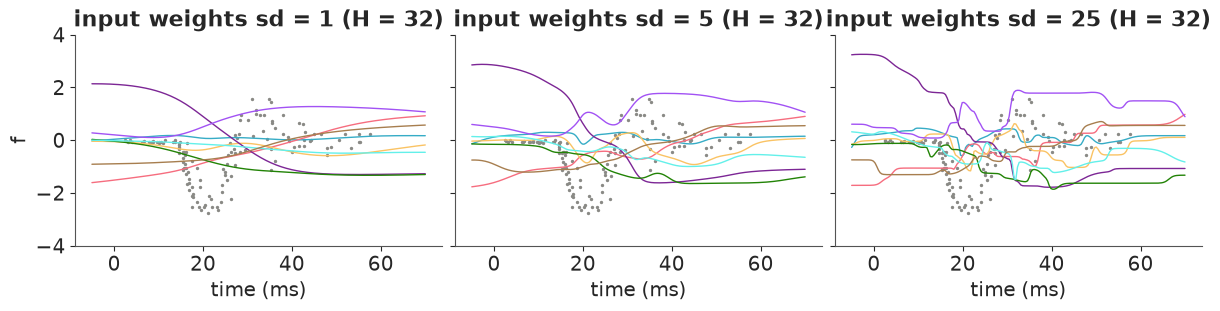

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, w_in in zip(axes, [1.0, 5.0, 25.0]):
    ax.plot(t_grid, prior_functions(8, 32, w_in=w_in, seed=3).T, lw=1)
    ax.scatter(t, y, s=2, color=GREY)
    ax.set(title=f"input weights sd = {w_in:g} (H = 32)", xlabel="time (ms)", ylim=(-4, 4))
axes[0].set_ylabel("f");

With standardised time (1 unit = 13 ms), sd 1 gives curves that barely bend over the
record; sd 25 gives kinks a fraction of a millisecond wide. The impact phase needs changes
over ~5 ms, somewhere in the middle. Rather than choose, **let the data choose**: put the
scale in a hyperprior (a layer-wise version of "automatic relevance determination", ARD):

- input layer: $W_j, b_j \sim N(0, \tau_{in})$, $\tau_{in} \sim \text{HalfNormal}(5)$ -
  anything from gentle to sharp;
- output heads: $w^f_j \sim N(0, \tau_f/\sqrt{H})$, $w^\sigma_j \sim N(0, \tau_\sigma/\sqrt{H})$,
  $\tau_f, \tau_\sigma \sim \text{HalfNormal}(1)$ - the swing of $f$ and of $\log\sigma$ are
  a priori of order one; $b^\sigma \sim N(-1, 1)$ as in E05.

**Knob 3: the parameterisation** - centred (sample $W$ given $\tau$) or non-centred
(sample $z \sim N(0, 1)$ and set $W = \tau z$). Both are built below, and both are fitted.

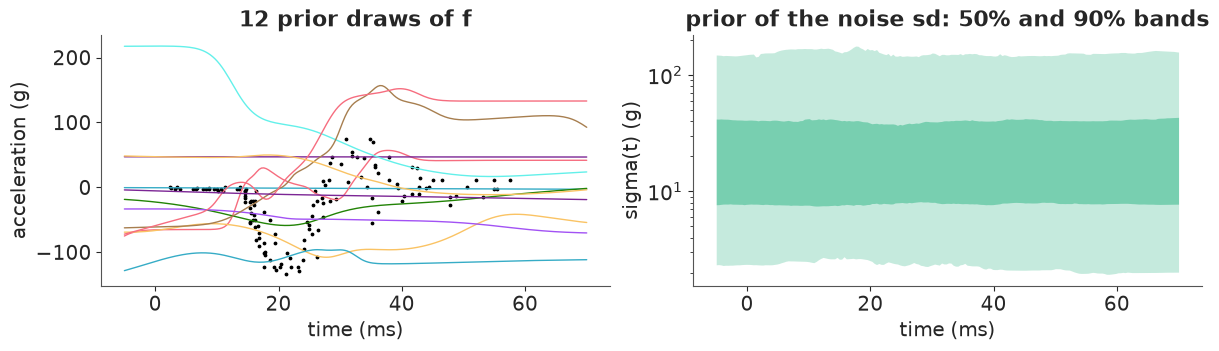

In [7]:
coords = {"hidden": np.arange(H)}


def build_mcycle_bnn(centred):
    with pm.Model(coords=coords) as model:
        xd = pm.Data("x", x[train])
        tau_in = pm.HalfNormal("tau_in", 5.0)
        tau_f = pm.HalfNormal("tau_f", 1.0)
        tau_s = pm.HalfNormal("tau_s", 1.0)
        scales = {"W1": tau_in, "b1": tau_in, "wf": tau_f / np.sqrt(H), "ws": tau_s / np.sqrt(H)}
        w = {}
        for name, scale in scales.items():
            if centred:
                w[name] = pm.Normal(name, 0, scale, dims="hidden")
            else:
                w[name] = pm.Deterministic(name, scale * pm.Normal(f"{name}_z", 0, 1, dims="hidden"),
                                           dims="hidden")
        bf = pm.Normal("bf", 0, 1)
        bs = pm.Normal("bs", -1, 1)
        h = pt.tanh(xd[:, None] * w["W1"] + w["b1"])
        f = h @ w["wf"] + bf
        log_s = h @ w["ws"] + bs
        pm.Normal("y", f, pt.exp(log_s), observed=y[train], shape=f.shape)
    return model


bnn_centred, bnn = build_mcycle_bnn(centred=True), build_mcycle_bnn(centred=False)
with bnn:
    prior = pm.sample_prior_predictive(1000, var_names=WEIGHTS, random_seed=RANDOM_SEED)
prior_w = {k: prior.prior[k].to_numpy().reshape(-1, *prior.prior[k].shape[2:]) for k in WEIGHTS}
f_prior, ls_prior = forward(prior_w, x_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(t_grid, f_prior[:12].T * ACCEL_SD, lw=1)
axes[0].scatter(t, y * ACCEL_SD, s=3, color="k")
axes[0].set(title="12 prior draws of f", xlabel="time (ms)", ylabel="acceleration (g)")
for q, alpha in [(0.05, 0.25), (0.25, 0.45)]:
    lo, hi = np.quantile(np.exp(ls_prior) * ACCEL_SD, [q, 1 - q], axis=0)
    axes[1].fill_between(t_grid, lo, hi, color=AQUA, alpha=alpha, lw=0)
axes[1].set(yscale="log", title="prior of the noise sd: 50% and 90% bands", xlabel="time (ms)",
            ylabel="sigma(t) (g)");

The prior functions have the right order of size (typically tens of g, occasionally 200 g;
the data reach -134 g) and range from nearly flat to sharply kinked; the noise sd can be anything from a couple of g to
over a hundred and can change along the record. Nothing absurd, nothing that knows the
answer.

## 4 · NUTS on a network, honestly

Both parameterisations, default nutpie settings apart from `target_accept=0.95`. (nutpie is
not bit-reproducible, so a rerun will give slightly different counts: read the numbers in
the text as rounded.)

In [8]:
def sample_timed(model, **kw):
    start = time.perf_counter()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    return idata, time.perf_counter() - start


nuts_log = {}
fits = {}
for label, model in [("centred", bnn_centred), ("non-centred", bnn)]:
    fits[label], seconds = sample_timed(model, target_accept=0.95)
    stats_ = fits[label].sample_stats
    rh, ess = rhat_ess(fits[label].posterior["tau_in"].to_numpy()[..., None])
    nuts_log[label] = {"wall time (s)": round(seconds), "divergences": int(stats_["diverging"].sum()),
                       "leapfrog steps per draw": round(float(stats_["n_steps"].mean())),
                       "draws at max depth (10)": int((stats_["depth"] >= 10).sum()),
                       "tau_in: r_hat": round(rh, 3), "tau_in: bulk ESS": round(ess)}
print("warm-up steps:", fits["non-centred"].posterior.attrs.get("tuning_steps"))
pd.DataFrame(nuts_log).T

warm-up steps: 400


,wall time (s),divergences,leapfrog steps per draw,draws at max depth (10),tau_in: r_hat,tau_in: bulk ESS
centred,26.0,61.0,999.0,3815.0,1.018,257.0
non-centred,28.0,47.0,1001.0,3867.0,1.000,3204.0


Two honest observations.

- **Every draw costs about a thousand gradient evaluations** - the tree-depth cap of
  $2^{10}$ - in both forms, for a network with only 69 parameters. The gradient is cheap here (100 readings), so a
  thousand of them per draw is affordable; for a network on 100,000 rows it would not be.
- **Non-centring does not remove the divergences**: both forms have a few dozen, and which
  has more changes from run to run. It is the right move for the scale hyperparameters -
  compare the ESS of $\tau_{in}$, many times higher - but the divergences are not mainly a
  funnel. Where are they?

In [9]:
nc = fits["non-centred"]
div = nc.sample_stats["diverging"].to_numpy().ravel()
w_nc = weight_draws(nc)
post_nc = nc.posterior
candidates = {
    "tau_in": post_nc["tau_in"].to_numpy().ravel(),
    "tau_f (output scale of f)": post_nc["tau_f"].to_numpy().ravel(),
    "tau_s (output scale of log sigma)": post_nc["tau_s"].to_numpy().ravel(),
    "sum of |wf| (total output weight)": np.abs(w_nc["wf"]).sum(axis=1),
    "steepest input weight max |W1|": np.abs(w_nc["W1"]).max(axis=1),
    "smallest sigma(t) on the data (g)": np.exp(forward(w_nc, x[train])[1]).min(axis=1) * ACCEL_SD,
}
pd.DataFrame({name: {"median, all draws": np.median(v), "median, divergent draws": np.median(v[div]),
                     "share of divergent draws above the overall median": np.mean(v[div] > np.median(v))}
              for name, v in candidates.items()}).T.round(2)

,"median, all draws","median, divergent draws",share of divergent draws above the overall median
tau_in,7.15,8.53,0.60
tau_f (output scale of f),1.63,2.15,0.81
tau_s (output scale of log sigma),1.73,2.15,0.72
sum of |wf| (total output weight),5.31,7.07,0.87
steepest input weight max |W1|,14.88,16.64,0.53
smallest sigma(t) on the data (g),1.32,0.84,0.26


If divergences had nothing to do with a quantity, about half of them would sit above its
median. The clearest signal is the **output side**: most divergent draws have a larger
total output weight $\sum_j |w^f_j|$ and larger $\tau_f$, $\tau_\sigma$ than typical
(the table shows by how much). That is a geometry specific to networks: two units with big
output weights of opposite sign can cancel, so a *family* of very different weight vectors
draws the same curve, and the sampler has to follow a narrow, curved ridge between them.
Non-centring the scales does not straighten that ridge. The divergences are a percent or
two of the draws; the usual remedies are a higher `target_accept`, a tighter prior on the
output scales, or fewer units. We keep them in view, and judge the result by what it
predicts for readings it has not seen (section 5).

### $\hat R$ on weights vs $\hat R$ on functions

E11 showed why weight-space diagnostics are the wrong question: permuting hidden units, or
flipping the sign of everything into and out of one tanh unit, leaves the function
unchanged, so the posterior contains $16! \times 2^{16} \approx 10^{18}$ copies of every
function. What must converge is what we report: $f$ and $\sigma$ on the grid, and the
log-likelihood.

In [10]:
def function_space_table(idata, model):
    post = idata.posterior
    n_chain, n_draw = post.sizes["chain"], post.sizes["draw"]
    f, log_s = forward(weight_draws(idata), x_grid)
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    quantities = {
        "weights (W1, b1, wf, ws)": np.concatenate([post[k].to_numpy() for k in ["W1", "b1", "wf", "ws"]], -1),
        "f(t) on a 200-point grid": f.reshape(n_chain, n_draw, -1),
        "log sigma(t) on the grid": log_s.reshape(n_chain, n_draw, -1),
        "log-likelihood (total)": idata.log_likelihood["y"].sum("y_dim_0").to_numpy(),
    }
    return pd.DataFrame({k: dict(zip(["max r_hat", "min bulk ESS"], rhat_ess(v)))
                         for k, v in quantities.items()}).T.round({"max r_hat": 3, "min bulk ESS": 0})


function_space_table(nc, bnn)

,max r_hat,min bulk ESS
"weights (W1, b1, wf, ws)",1.049,68.0
f(t) on a 200-point grid,1.003,1495.0
log sigma(t) on the grid,1.004,1352.0
log-likelihood (total),1.002,1111.0


The weights have $\hat R$ up to about 1.05 and ESS below 100; every function-space quantity
is converged, with over a thousand effective draws. Here the weight $\hat R$ happens to be
only mildly bad - the chains move between symmetric copies often enough - but it would
not matter if it were 2: it measures which *copy* a chain is in, not what we care about.
What the weights *do* say, once turned into a symmetric quantity, is where the network
puts its bends. The point where unit $j$ crosses zero, $t = -b_j/W_j$, is unchanged by a
sign flip, and pooling it over units ignores the labels:

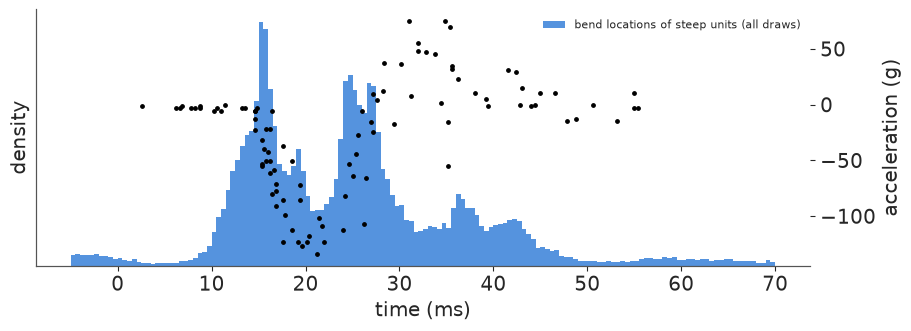

In [11]:
switch = (-w_nc["b1"] / w_nc["W1"]) * T_SD + T_MU  # (draws, units), in ms
steep_enough = np.abs(w_nc["W1"]) > 2  # a tanh that turns within ~13 ms / 2
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(switch[steep_enough], bins=np.linspace(-5, 70, 151), color=BLUE, density=True, alpha=0.8,
        label="bend locations of steep units (all draws)")
ax2 = ax.twinx()
ax2.scatter(t[train], y[train] * ACCEL_SD, s=6, color="k")
ax2.set_ylabel("acceleration (g)")
ax.set(xlabel="time (ms)", ylabel="density", yticks=[])
ax.legend(loc="upper right", fontsize=8);

The steep units pile up where the curve turns: at the onset of the impact (~15 ms), on the
way out of the trough (~25-27 ms), and in smaller numbers around the rebound's peak and
decline (35-42 ms). That is the network's
"basis", learned from the data rather than fixed like HSGP's sines. Now the fit itself:

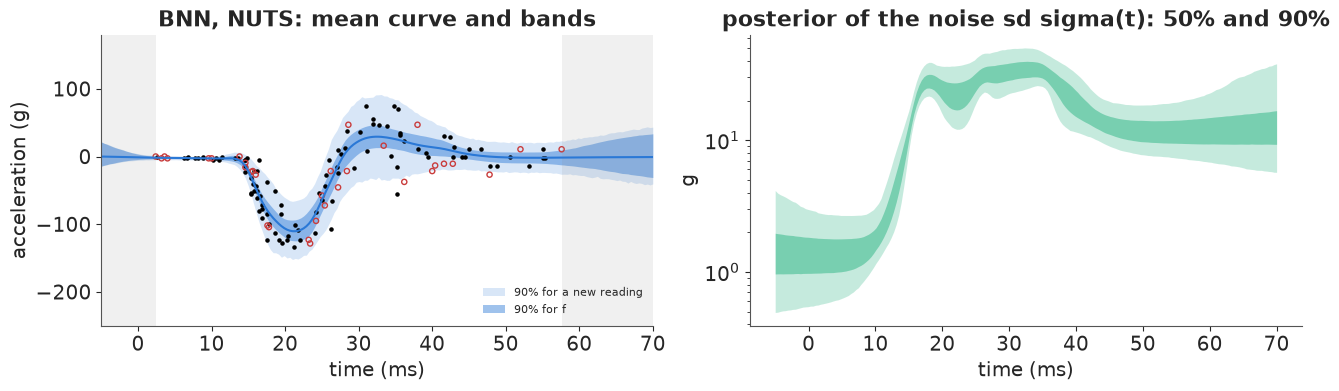

In [12]:
def bands(f, log_s, draws_per=1, seed=0):
    """Mean of f, 90% band of f and 90% band of a new reading, in g."""
    r = np.random.default_rng(seed)
    y_new = f + np.exp(log_s) * r.standard_normal(f.shape)
    return (f.mean(0) * ACCEL_SD, *(np.quantile(f, [0.05, 0.95], 0) * ACCEL_SD),
            *(np.quantile(y_new, [0.05, 0.95], 0) * ACCEL_SD))


def plot_band(ax, f, log_s, color, title):
    mean, flo, fhi, ylo, yhi = bands(f, log_s)
    ax.fill_between(t_grid, ylo, yhi, color=color, alpha=0.18, lw=0, label="90% for a new reading")
    ax.fill_between(t_grid, flo, fhi, color=color, alpha=0.45, lw=0, label="90% for f")
    ax.plot(t_grid, mean, color=color, lw=1.5)
    ax.scatter(t[train], y[train] * ACCEL_SD, s=5, color="k")
    ax.scatter(t[test], y[test] * ACCEL_SD, s=14, facecolor="none", edgecolor=RED)
    ax.axvspan(-5, t.min(), color=GREY, alpha=0.12, lw=0)
    ax.axvspan(t.max(), 70, color=GREY, alpha=0.12, lw=0)
    ax.set(title=title, ylim=(-250, 180), xlim=(-5, 70))


f_nuts, ls_nuts = forward(w_nc, x_grid)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_band(axes[0], f_nuts, ls_nuts, BLUE, "BNN, NUTS: mean curve and bands")
axes[0].set(xlabel="time (ms)", ylabel="acceleration (g)")
axes[0].legend(loc="lower right", fontsize=8)
for q, alpha in [(0.05, 0.25), (0.25, 0.45)]:
    lo, hi = np.quantile(np.exp(ls_nuts) * ACCEL_SD, [q, 1 - q], axis=0)
    axes[1].fill_between(t_grid, lo, hi, color=AQUA, alpha=alpha, lw=0)
axes[1].set(yscale="log", title="posterior of the noise sd sigma(t): 50% and 90%", xlabel="time (ms)",
            ylabel="g");

The fit reproduces what E05's two-GP model found: a noise sd of one or two g before the
impact and tens of g after it. (Grey shading marks times outside the record.) The held-out
readings (red circles) sit where the bands say they should. Outside the record the
network does what tanh units do: each unit saturates, so the mean curve flattens, and the
band for $f$ widens only slowly. We come back to that against the GP in section 6.

## 5 · The cheap alternatives, judged on held-out data

NUTS took under a minute here, but for bigger networks people reach for cheaper tools.
Five of them, all on the same non-centred model:

- **mean-field ADVI** and **full-rank ADVI** (`pm.fit`, 30,000 steps from the default start);
- **Pathfinder** (`pmx.fit_pathfinder`, 8 paths; `parallel=False` as in E11);
- a **deep ensemble**, in its Bayesian-workflow form: ten MAP fits (`pm.find_MAP`) from
  random starts, pooled with equal weights - each member contributes $f$ and $\sigma(t)$;
- **ADVI started from the best MAP** with a small initial sd, to separate "the optimiser
  got lost" from "the objective prefers something else".

Each is scored on the 33 held-out readings by the **log predictive density** (the sum over
test points of $\log \frac1S\sum_s p(y_i \mid \theta_s)$; higher is better, the out-of-sample
version of elpd) and by the coverage and width of its 90% predictive interval.

In [13]:
def test_scores(f, log_s, seed=0):
    """Pointwise log predictive density on the test set, coverage and width of 90% intervals."""
    r = np.random.default_rng(seed)
    sd = np.exp(log_s)
    lpd = logsumexp(stats.norm.logpdf(y[test], f, sd), axis=0) - np.log(len(f))
    y_new = f + sd * r.standard_normal(f.shape)
    lo, hi = np.quantile(y_new, [0.05, 0.95], axis=0)
    pit = stats.norm.cdf((y[test] - f) / sd).mean(0)
    return {"lpd": lpd, "coverage": np.mean((y[test] >= lo) & (y[test] <= hi)),
            "width": np.mean(hi - lo) * ACCEL_SD, "pit": pit}


approx_w, approx_time = {"NUTS": w_nc}, {"NUTS": nuts_log["non-centred"]["wall time (s)"]}

for label, method in [("mean-field ADVI", "advi"), ("full-rank ADVI", "fullrank_advi")]:
    start = time.perf_counter()
    with bnn:
        vi = pm.fit(n=30_000, method=method, random_seed=RANDOM_SEED, progressbar=False)
        approx_w[label] = weight_draws(vi.sample(1000, random_seed=RANDOM_SEED))
    approx_time[label] = round(time.perf_counter() - start)

start = time.perf_counter()
with bnn:
    pf = pmx.fit_pathfinder(num_paths=8, num_draws=1000, parallel=False, progressbar=False,
                            random_seed=RANDOM_SEED)
approx_w["Pathfinder"] = weight_draws(pf)
approx_time["Pathfinder"] = round(time.perf_counter() - start)

start = time.perf_counter()
ip = bnn.initial_point()
logp_fn = bnn.compile_logp()
maps, map_logp = [], []
for k in range(10):
    r = np.random.default_rng(100 + k)
    with bnn:
        mp = pm.find_MAP(start={n: v + r.normal(0, 1, np.shape(v)) for n, v in ip.items()},
                         progressbar=False, maxeval=20_000)
    maps.append(mp)
    map_logp.append(float(logp_fn({n: mp[n] for n in ip})))
members = {k: np.stack([np.asarray(mp[k]) for mp in maps]) for k in WEIGHTS}
approx_w["MAP ensemble (10)"] = {k: np.repeat(v, 100, axis=0) for k, v in members.items()}
approx_time["MAP ensemble (10)"] = round(time.perf_counter() - start)

best = maps[int(np.argmax(map_logp))]
start = time.perf_counter()
with bnn:
    vi = pm.fit(n=30_000, method=pm.ADVI(start={n: best[n] for n in ip},
                                         start_sigma={n: np.full(np.shape(v), 0.05) for n, v in ip.items()},
                                         random_seed=RANDOM_SEED), progressbar=False)
    approx_w["ADVI from best MAP"] = weight_draws(vi.sample(1000, random_seed=RANDOM_SEED))
approx_time["ADVI from best MAP"] = round(time.perf_counter() - start)  # plus one MAP fit

scores = {k: test_scores(*forward(w, x[test])) for k, w in approx_w.items()}
tau_draws = {"NUTS": nc.posterior["tau_in"].to_numpy().ravel()}


def scoreboard(scores, times, reference="NUTS"):
    ref = scores[reference]["lpd"]
    return pd.DataFrame({k: {
        "time (s)": times.get(k, np.nan),
        "test lpd (33 pts)": s["lpd"].sum(),
        f"difference to {reference}": s["lpd"].sum() - ref.sum(),
        "se of difference": np.std(s["lpd"] - ref) * np.sqrt(len(ref)),
        "90% coverage": s["coverage"],
        "90% width (g)": s["width"],
    } for k, s in scores.items()}).T.round(2)


scoreboard(scores, approx_time)

,time (s),test lpd (33 pts),difference to NUTS,se of difference,90% coverage,90% width (g)
NUTS,28.0,-4.67,0.00,0.00,0.94,65.77
mean-field ADVI,3.0,-44.00,-39.33,6.99,0.94,172.39
full-rank ADVI,3.0,-43.38,-38.71,7.32,0.94,168.48
Pathfinder,2.0,-42.40,-37.73,6.61,0.97,192.90
MAP ensemble (10),6.0,-16.80,-12.14,5.08,0.61,44.84
ADVI from best MAP,2.0,-21.78,-17.11,4.91,1.00,102.47


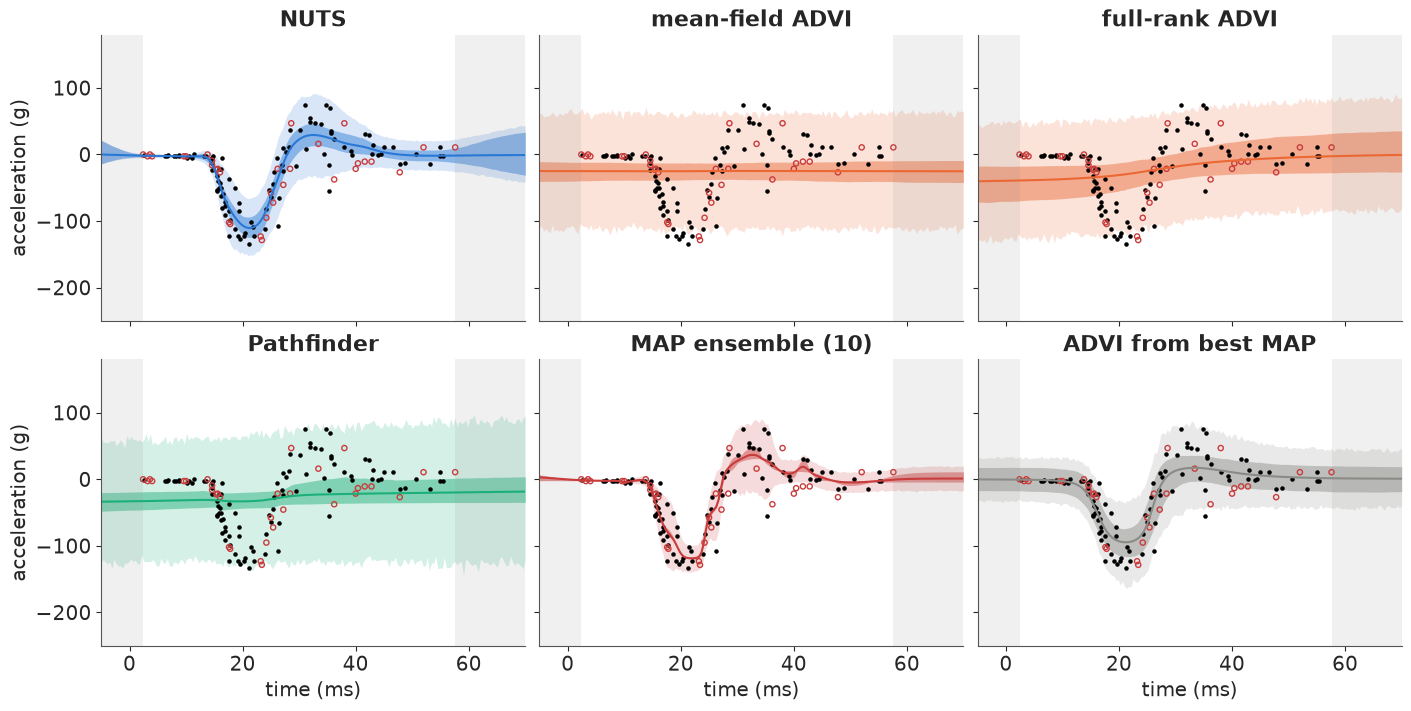

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, (label, w), color in zip(axes.flat, approx_w.items(), [BLUE, ORANGE, ORANGE, AQUA, RED, GREY]):
    plot_band(ax, *forward(w, x_grid), color, label)
for ax in axes[:, 0]:
    ax.set_ylabel("acceleration (g)")
for ax in axes[1]:
    ax.set_xlabel("time (ms)");

This is the most important figure of the notebook.

**Both ADVIs and Pathfinder ignore the data.** They settle on a network that is almost
switched off - a nearly flat $f$ - and explain every reading as noise, with a 90% interval
about 170-190 g wide everywhere. Their coverage is fine (the interval covers 94-97% of the
held-out readings) and completely useless: this is why coverage alone is never a
calibration check, and why the log predictive density, which punishes a vague forecast,
puts them nearly 40 units behind NUTS - five to six standard errors. The phenomenon is known: with a factorised (or, here,
Gaussian) approximation, the KL term makes it cheaper to *prune* the hidden units - set
them to their prior - than to represent the tight, curved correlations between input and
output weights that a working unit needs (Trippe & Turner 2017; Coker et al. 2022 prove
that wide mean-field BNNs converge to the prior predictive regardless of the data). It is
the same failure E11 saw on its correction term, pushed to the limit. Full-rank ADVI does
no better: its approximation is still one Gaussian.

**Started from a good MAP, ADVI walks away from it** (bottom right): the fit keeps the
impact, but its 90% interval is 80-100 g wide even before the impact, where the readings
vary by a couple of g. The objective itself, not the optimiser, prefers the pruned
solution.

**The MAP ensemble has the opposite problem**: every member fits the training data closely,
with sharp units ($\tau_{in}$ at the MAP is about twice the posterior mean) and noise sds
shrunk to fit the residuals, so the members agree with each other and the pooled interval
is too narrow: it covers only about 60% of the held-out readings, and its lpd is behind
NUTS by about two standard errors. Its members are also very uneven: the ten local optima
differ in log posterior by a few units, and their individual test lpds differ by far more:

In [15]:
member_lpd = [test_scores(*forward({k: v[i:i + 1] for k, v in members.items()}, x[test]))["lpd"].sum()
              for i in range(10)]
pd.DataFrame({"log posterior at the MAP": map_logp, "test lpd of this member alone": member_lpd,
              "tau_in at the MAP": [float(mp["tau_in"]) for mp in maps]}).round(1).sort_values(
    "log posterior at the MAP", ascending=False).T

,3,7,4,9,2,6,8,1,0,5
log posterior at the MAP,-82.7,-82.8,-83.3,-84.3,-84.5,-84.6,-84.7,-84.8,-84.9,-85.6
test lpd of this member alone,-80.4,-25.3,-78.7,-79.5,-268.6,-13.8,-14.5,-27.5,-15.0,-14.6
tau_in at the MAP,16.8,18.4,16.0,15.1,17.4,16.4,16.6,17.3,15.6,15.7


A single MAP network is a gamble, and the log posterior at the optimum is no guide to
which ones lost: the members' test lpds range from about -15 to below -250, with no
relation to their ranking in the first row. The bad ones bought their fit with near-zero
noise sds that a few held-out readings then contradict. (These optima vary slightly from
run to run - L-BFGS on this landscape is sensitive to rounding - but the spread does not.)
Posterior mass is not at the modes. The NUTS posterior averages over
$\tau_{in}$ values around 7 and over a whole family of curves, and it is the only method
here that is both sharp where the data are dense and calibrated on unseen readings.

### A cheap middle ground: the last-layer Laplace approximation

The practical compromise in the deep-learning literature (Kristiadi et al. 2020; Daxberger
et al. 2021): train the network by MAP, freeze the hidden layer, and treat only the output
weights as Bayesian. For a Gaussian likelihood with the noise sd fixed at its MAP value,
$f = \Phi w$ is a linear model in the frozen features $\Phi$, so the posterior of $w$ is
Gaussian in closed form - no sampling at all. Here with the best MAP's features and its
$\tau_f$ for the prior:

In [16]:
def last_layer(mp, n_draws=4000):
    P = {k: np.asarray(mp[k]) for k in WEIGHTS}

    def features(xs):
        return np.c_[np.tanh(xs[:, None] * P["W1"] + P["b1"]), np.ones(len(xs))]

    def log_sigma(xs):
        return np.tanh(xs[:, None] * P["W1"] + P["b1"]) @ P["ws"] + P["bs"]

    Phi, s = features(x[train]), np.exp(log_sigma(x[train]))
    prior_var = np.r_[np.full(H, float(mp["tau_f"]) ** 2 / H), 1.0]
    cov = np.linalg.inv(Phi.T @ (Phi / s[:, None] ** 2) + np.diag(1 / prior_var))
    mean = cov @ (Phi.T @ (y[train] / s ** 2))
    w_out = np.random.default_rng(RANDOM_SEED).multivariate_normal(mean, cov, n_draws)

    def predict(xs):
        return w_out @ features(xs).T, np.broadcast_to(log_sigma(xs), (n_draws, len(xs)))

    return predict


ll_predict = last_layer(best)
scores["last-layer Laplace"] = test_scores(*ll_predict(x[test]))
scoreboard({k: scores[k] for k in ["NUTS", "MAP ensemble (10)", "last-layer Laplace"]}, approx_time)

,time (s),test lpd (33 pts),difference to NUTS,se of difference,90% coverage,90% width (g)
NUTS,28.0,-4.67,0.00,0.00,0.94,65.77
MAP ensemble (10),6.0,-16.80,-12.14,5.08,0.61,44.84
last-layer Laplace,NaN,-55.54,-50.87,22.11,0.70,45.75


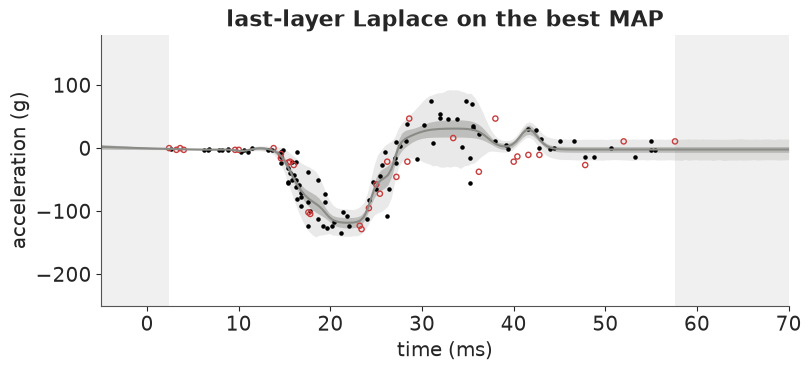

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.6))
plot_band(ax, *ll_predict(x_grid), GREY, "last-layer Laplace on the best MAP")
ax.set(xlabel="time (ms)", ylabel="acceleration (g)");

It costs nothing beyond the MAP fit, and it inherits the MAP's problems: the frozen
features are the overfitted ones, and the noise sd is the MAP's shrunken one. The band for
$f$ is narrow and wiggles through the training readings, and the test lpd is far behind
NUTS - tens of units, about as bad as the ADVIs' - with a large standard error because a
handful of held-out readings fall far outside its narrow band. The "best" MAP by log
posterior is one of the members that generalise badly (table above), and a Bayesian last
layer cannot repair its features. The last-layer idea works best when the features come from a network trained on far
more data than this, where a MAP is a good summary; on 100 readings the uncertainty in the
*features* is most of the uncertainty.

## 6 · The GP of E05 as the opponent

E05's heteroskedastic model - an HSGP for $f$ and a second HSGP for $\log\sigma$, both
Matérn-5/2 with an inverse-gamma lengthscale prior putting 90% of its mass between 3 and
25 ms - refitted on the same 100 training readings. One change: E05 sampled the full data
without divergences at `target_accept=0.95`, but on this subset it produced about a
hundred (in a trial run), so we use 0.99; a couple of dozen remain, and the lengthscale
`ell` mixes slowly ($\hat R$ 1.02, ESS about 200) - the GP is not effortless on 100 points
either.

In [18]:
ell_prior = pz.maxent(pz.InverseGamma(), lower=3, upper=25, mass=0.9, plot=False)
ELL_ALPHA, ELL_BETA = float(ell_prior.alpha), float(ell_prior.beta)
m_rec, c_rec = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[t.min(), t.max()], lengthscale_range=[3, 25], cov_func="matern52")
print(f"HSGP: m = {m_rec}, c = {c_rec:.2f}, "
      f"domain [{t.mean() - c_rec * np.ptp(t) / 2:.0f}, {t.mean() + c_rec * np.ptp(t) / 2:.0f}] ms")

with pm.Model() as gp_model:
    X = pm.Data("X", t[train][:, None])
    ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta = pm.HalfNormal("eta", 1.5)
    gp_f = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="centered",
                      cov_func=eta**2 * pm.gp.cov.Matern52(1, ls=ell))
    f_gp = gp_f.prior("f", X=X)
    ell_g = pm.InverseGamma("ell_g", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta_g = pm.HalfNormal("eta_g", 1.5)
    s0 = pm.Normal("s0", -1, 1)
    gp_g = pm.gp.HSGP(m=[m_rec], c=c_rec, parametrization="noncentered",
                      cov_func=eta_g**2 * pm.gp.cov.Matern52(1, ls=ell_g))
    g = gp_g.prior("g", X=X)
    pm.Deterministic("log_s", s0 + g)
    pm.Normal("y", f_gp, pm.math.exp(s0 + g), observed=y[train], shape=f_gp.shape)

start = time.perf_counter()
with freeze_dims_and_data(gp_model):
    gp_idata = pm.sample(target_accept=0.99, random_seed=RANDOM_SEED, progressbar=False)
approx_time["HSGP (E05)"] = round(time.perf_counter() - start)
print("divergences:", int(gp_idata.sample_stats["diverging"].sum()))
az.summary(gp_idata, var_names=["ell", "eta", "ell_g", "eta_g", "s0"], round_to=2)

HSGP: m = 90, c = 3.71, domain [-77, 128] ms


divergences: 22


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,7.61,1.72,5.25,10.65,221.01,281.65,1.02,0.12,0.08
eta,1.15,0.41,0.69,1.90,277.93,411.85,1.01,0.03,0.03
ell_g,9.59,3.51,5.19,15.78,2227.69,2369.29,1.00,0.07,0.08
eta_g,1.53,0.52,0.88,2.50,2040.69,2489.11,1.00,0.01,0.01
s0,-1.42,0.64,-2.40,-0.38,2171.63,2098.38,1.00,0.01,0.01


In [19]:
with gp_model:
    pm.set_data({"X": np.r_[t[test], t_grid][:, None]})
    gp_pred = pm.sample_posterior_predictive(gp_idata, var_names=["f", "log_s"], predictions=True,
                                             random_seed=RANDOM_SEED, progressbar=False)
gp_f_all = gp_pred.predictions["f"].to_numpy().reshape(-1, len(test) + len(t_grid))
gp_ls_all = gp_pred.predictions["log_s"].to_numpy().reshape(-1, len(test) + len(t_grid))
scores["HSGP (E05)"] = test_scores(gp_f_all[:, :len(test)], gp_ls_all[:, :len(test)])
f_gp_grid, ls_gp_grid = gp_f_all[:, len(test):], gp_ls_all[:, len(test):]
del gp_pred, gp_f_all, gp_ls_all
scoreboard({k: scores[k] for k in ["NUTS", "HSGP (E05)", "MAP ensemble (10)"]}, approx_time)

,time (s),test lpd (33 pts),difference to NUTS,se of difference,90% coverage,90% width (g)
NUTS,28.0,-4.67,0.00,0.00,0.94,65.77
HSGP (E05),17.0,-8.08,-3.41,1.45,1.00,66.79
MAP ensemble (10),6.0,-16.80,-12.14,5.08,0.61,44.84


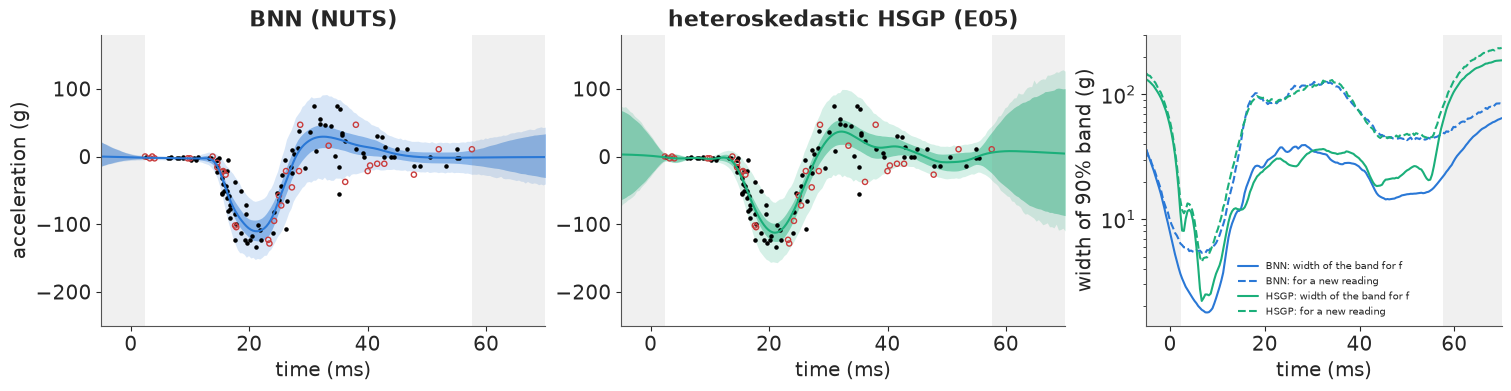

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1, 1, 0.8]})
plot_band(axes[0], f_nuts, ls_nuts, BLUE, "BNN (NUTS)")
plot_band(axes[1], f_gp_grid, ls_gp_grid, AQUA, "heteroskedastic HSGP (E05)")
axes[0].set(xlabel="time (ms)", ylabel="acceleration (g)")
axes[1].set(xlabel="time (ms)")
for f_, ls_, color, label in [(f_nuts, ls_nuts, BLUE, "BNN"), (f_gp_grid, ls_gp_grid, AQUA, "HSGP")]:
    _, flo, fhi, ylo, yhi = bands(f_, ls_)
    axes[2].plot(t_grid, fhi - flo, color=color, label=f"{label}: width of the band for f")
    axes[2].plot(t_grid, yhi - ylo, color=color, ls="--", label=f"{label}: for a new reading")
axes[2].axvspan(-5, t.min(), color=GREY, alpha=0.12, lw=0)
axes[2].axvspan(t.max(), 70, color=GREY, alpha=0.12, lw=0)
axes[2].set(yscale="log", xlabel="time (ms)", ylabel="width of 90% band (g)", xlim=(-5, 70))
axes[2].legend(fontsize=7);

Inside the record the two draw nearly the same picture. On the held-out readings the BNN
scores a little better (the difference is about two of its standard errors, on 33
points), and the GP's 90% interval covers every held-out reading - slightly
conservative, as in E05. Both are far ahead of the MAP ensemble. The GP needed no
new design beyond E05's lengthscale prior, its hyperparameters mean something, and it took
a few seconds of sampling; the network needed the three knobs of section 3 and a
thousand leapfrog steps per draw.

The real difference is **outside the record** (grey), and it is a difference of *prior*,
not of method. The Matérn GP forgets the data within a lengthscale or two: its mean
returns to 0 and its band for $f$ widens towards the prior amplitude, to 150-200 g -
"I do not know". The tanh network extrapolates each unit's saturated value: its mean
stays flat and its band for $f$ grows too, but to less than half the GP's width -
"things probably carry on as they were". For a crash that has settled, that answer
happens to be plausible; the network would be just as sure about a quantity that was
about to change. Neither is "right": a BNN's out-of-data behaviour is whatever its
activation and prior imply, and you should look at it (as here) before trusting it. One of
the most-cited arguments for BNNs is honest uncertainty away from the data; with tanh units
and one hidden layer that honesty is modest, and a GP is the better tool if that is the
point.

### Calibration: PIT

If the predictive distribution is right, the probability integral transform of each
held-out reading, $\text{PIT}_i = P(y^{new}_i \le y_i)$, is uniform. With 33 readings a
histogram of five bins is all we can afford, so read it for gross shapes only: a U means
too narrow, a hump means too wide.

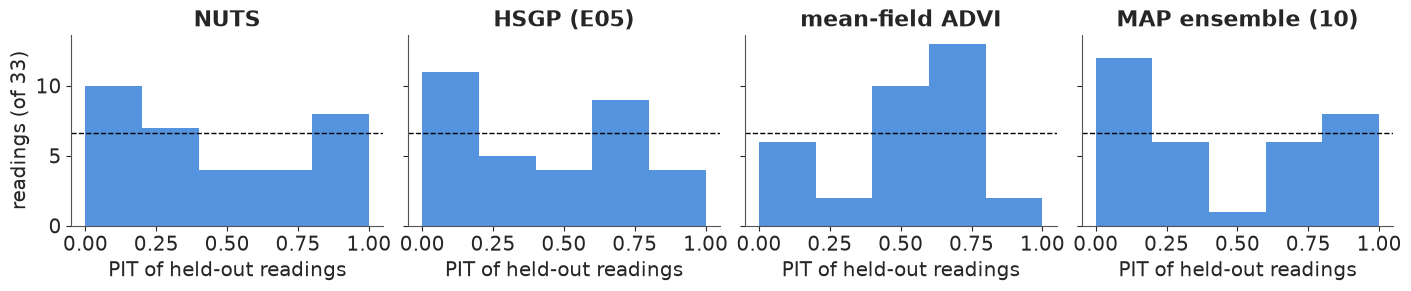

In [21]:
pit_methods = ["NUTS", "HSGP (E05)", "mean-field ADVI", "MAP ensemble (10)"]
fig, axes = plt.subplots(1, 4, figsize=(14, 2.8), sharey=True)
for ax, label in zip(axes, pit_methods):
    ax.hist(scores[label]["pit"], bins=np.linspace(0, 1, 6), color=BLUE, alpha=0.8)
    ax.axhline(len(test) / 5, color="k", ls="--", lw=1)
    ax.set(title=label, xlabel="PIT of held-out readings")
axes[0].set_ylabel("readings (of 33)");

With 33 readings a bin count wanders by about $\pm 2.5$ around the expected 6.6 by chance
alone, so NUTS and the GP show nothing beyond noise. Mean-field ADVI piles its PIT values
in the middle - every reading is unremarkable to a model that thinks everything is noise.
The MAP ensemble has an almost empty middle bin and a crowded first one: readings land in
its tails more often than a correct predictive distribution allows.

## 7 · A tabular task: concrete strength

One dimension is a GP's home ground. A BNN's case is stronger with several inputs that
interact, where a GP needs a kernel design and a GLM needs someone to guess the
interactions. Yeh (1998) measured the compressive strength of 1030 concrete cylinders with
different mixes at ages from 1 to 365 days; it is one of the standard UCI benchmarks of the
BNN literature (Hernández-Lobato & Adams 2015). Strength depends on ingredients in
non-additive ways (the water-to-cement ratio is the classic) and grows with age at a rate
that depends on the mix (slag and fly ash cement react slowly).

In [22]:
data.describe("concrete")
concrete = data.load("concrete")
concrete["log_age"] = np.log(concrete.age)
FEATS = ["cement", "slag", "ash", "water", "superplastic", "coarseagg", "fineagg", "log_age"]
Y_MU, Y_SD = concrete.strength.mean(), concrete.strength.std()
print(concrete.age.value_counts().sort_index().to_dict())
concrete.describe().round(1)

concrete: 1030 laboratory concrete cylinders: mix ingredients in kg per m3 of concrete (cement, blast-furnace slag, fly ash, water, superplasticizer, coarse and fine aggregate), age at testing (1-365 days) and compressive strength (MPa).
  source: Yeh (1998, Cement and Concrete Research 28:1797), 'Modeling of strength of high-performance concrete using artificial neural networks'; UCI Machine Learning Repository (CSV copy from the datasets of Lantz, Machine Learning with R); a standard Bayesian-neural-network benchmark (Hernandez-Lobato & Adams 2015).
  url:    https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv
{1: 2, 3: 134, 7: 126, 14: 62, 28: 425, 56: 91, 90: 54, 91: 22, 100: 52, 120: 3, 180: 26, 270: 13, 360: 6, 365: 14}


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,log_age
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,281.2,73.9,54.2,181.6,6.2,972.9,773.6,45.7,35.8,3.2
std,104.5,86.3,64.0,21.4,6.0,77.8,80.2,63.2,16.7,1.2
min,102.0,0.0,0.0,121.8,0.0,801.0,594.0,1.0,2.3,0.0
25%,192.4,0.0,0.0,164.9,0.0,932.0,731.0,7.0,23.7,1.9
50%,272.9,22.0,0.0,185.0,6.4,968.0,779.5,28.0,34.4,3.3
75%,350.0,143.0,118.3,192.0,10.2,1029.4,824.0,56.0,46.1,4.0
max,540.0,359.4,200.1,247.0,32.2,1145.0,992.6,365.0,82.6,5.9


We use age on the log scale for every model, so that the GLMs get the obvious
transformation for free. Two held-out tests:

1. **random**: 250 cylinders chosen at random (in-distribution);
2. **old concrete**: train on ages up to 56 days, predict the 190 cylinders tested at 90-365
   days - an extrapolation along the one input that matters most.

Three models, all with Normal noise on standardised strength:

- **GLM**: linear in the eight standardised inputs;
- **GLM+**: plus the curvature in log age and a cement x age interaction (what a first
  round of feature engineering would add);
- **BNN**: 16 tanh units with **ARD** - one scale per input, $W_{pj} = \tau_p z_{pj}$ with
  $\tau_p \sim \text{HalfNormal}(1)$, so the data can switch an input's effect on or off;
  output weights with the $\tau_{out}/\sqrt{H}$ scaling. Non-centred throughout.

In [23]:
def concrete_split(test_rows):
    is_test = np.zeros(len(concrete), bool)
    is_test[test_rows] = True
    tr, te = concrete[~is_test], concrete[is_test]
    mu, sd = tr[FEATS].mean(), tr[FEATS].std()  # standardise with training statistics only
    return {"X_train": ((tr[FEATS] - mu) / sd).to_numpy(), "y_train": (tr.strength.to_numpy() - Y_MU) / Y_SD,
            "X_test": ((te[FEATS] - mu) / sd).to_numpy(), "y_test": (te.strength.to_numpy() - Y_MU) / Y_SD,
            "mu": mu, "sd": sd}


splits = {"random": concrete_split(rng.permutation(len(concrete))[:250]),
          "old concrete": concrete_split(np.where(concrete.age >= 90)[0])}


def glm_design(X, extra):
    return np.c_[X, X[:, 7] ** 2, X[:, 0] * X[:, 7]] if extra else X


def fit_glm(split, extra):
    with pm.Model() as model:
        Xd = glm_design(split["X_train"], extra)
        beta = pm.Normal("beta", 0, 1, shape=Xd.shape[1])
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("y", alpha + Xd @ beta, sigma, observed=split["y_train"])
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    post = idata.posterior

    def predict(X):
        beta_ = post["beta"].to_numpy().reshape(-1, post["beta"].shape[-1])
        mean = post["alpha"].to_numpy().reshape(-1, 1) + beta_ @ glm_design(X, extra).T
        return mean, np.broadcast_to(post["sigma"].to_numpy().reshape(-1, 1), mean.shape)

    return predict, idata


def build_concrete_bnn(split):
    with pm.Model(coords={"feature": FEATS, "hidden": np.arange(H)}) as model:
        ard = pm.HalfNormal("ard", 1.0, dims="feature")
        W1 = pm.Deterministic("W1", ard[:, None] * pm.Normal("W1_z", 0, 1, dims=("feature", "hidden")),
                              dims=("feature", "hidden"))
        b1 = pm.Normal("b1", 0, 1, dims="hidden")
        tau_out = pm.HalfNormal("tau_out", 1.0)
        w2 = pm.Deterministic("w2", tau_out / np.sqrt(H) * pm.Normal("w2_z", 0, 1, dims="hidden"), dims="hidden")
        b2 = pm.Normal("b2", 0, 1)
        sigma = pm.HalfNormal("sigma", 1)
        mean = pt.tanh(split["X_train"] @ W1 + b1) @ w2 + b2
        pm.Normal("y", mean, sigma, observed=split["y_train"])
    return model


def bnn_predictor(idata):
    post = idata.posterior
    W1 = post["W1"].to_numpy().reshape(-1, len(FEATS), H)
    b1, w2 = (post[k].to_numpy().reshape(-1, H) for k in ["b1", "w2"])
    b2, sigma = (post[k].to_numpy().reshape(-1, 1) for k in ["b2", "sigma"])

    def predict(X):
        mean = np.einsum("snh,sh->sn", np.tanh(np.einsum("np,sph->snh", X, W1) + b1[:, None]), w2) + b2
        return mean, np.broadcast_to(sigma, mean.shape)

    return predict


def concrete_scores(mean, sd, y_test):
    lpd = logsumexp(stats.norm.logpdf(y_test, mean, sd), axis=0) - np.log(len(mean))
    y_new = mean + sd * np.random.default_rng(0).standard_normal(mean.shape)
    lo, hi = np.quantile(y_new, [0.05, 0.95], axis=0)
    return {"lpd": lpd, "rmse (MPa)": np.sqrt(np.mean((mean.mean(0) - y_test) ** 2)) * Y_SD,
            "90% coverage": np.mean((y_test >= lo) & (y_test <= hi)),
            "90% width (MPa)": np.mean(hi - lo) * Y_SD,
            "pit": stats.norm.cdf((y_test - mean) / sd).mean(0)}


concrete_results, predictors, concrete_fits = {}, {}, {}
for split_name, split in splits.items():
    for label, extra in [("GLM", False), ("GLM+", True)]:
        start = time.perf_counter()
        predictors[split_name, label], _ = fit_glm(split, extra)
        seconds = time.perf_counter() - start
        concrete_results[split_name, label] = {
            "time (s)": seconds, **concrete_scores(*predictors[split_name, label](split["X_test"]), split["y_test"])}
    concrete_fits[split_name], seconds = sample_timed(build_concrete_bnn(split), target_accept=0.9)
    predictors[split_name, "BNN"] = bnn_predictor(concrete_fits[split_name])
    concrete_results[split_name, "BNN"] = {
        "time (s)": seconds, **concrete_scores(*predictors[split_name, "BNN"](split["X_test"]), split["y_test"])}


def concrete_table():
    rows = {}
    for (split_name, label), r in concrete_results.items():
        ref = concrete_results[split_name, "BNN"]["lpd"]
        rows[split_name, label] = {
            "time (s)": round(r["time (s)"]), "n test": len(r["lpd"]),
            "lpd per cylinder": r["lpd"].mean(),
            "lpd diff to BNN (total)": r["lpd"].sum() - ref.sum(),
            "se of diff": np.std(r["lpd"] - ref) * np.sqrt(len(ref)),
            "rmse (MPa)": r["rmse (MPa)"], "90% coverage": r["90% coverage"],
            "90% width (MPa)": r["90% width (MPa)"]}
    return pd.DataFrame(rows).T.round(2)


concrete_table()

time (s)  n test  lpd per cylinder  \
random       GLM        1.0   250.0             -0.60   
             GLM+       1.0   250.0             -0.59   
             BNN       83.0   250.0              0.07   
old concrete GLM        1.0   190.0             -0.97   
             GLM+       1.0   190.0             -1.70   
             BNN       92.0   190.0             -0.55   

                   lpd diff to BNN (total)  se of diff  rmse (MPa)  \
random       GLM                   -168.19       15.25        7.36   
             GLM+                  -165.03       14.96        7.27   
             BNN                      0.00        0.00        4.10   
old concrete GLM                    -79.03       11.51        9.45   
             GLM+                  -218.47       23.33       13.34   
             BNN                      0.00        0.00        7.94   

                   90% coverage  90% width (MPa)  
random       GLM           0.87            23.51  
             GLM+          0.88            23.26  
             BNN           0.93            13.53  
old concrete GLM           0.75            22.63  
             GLM+          0.66            23.23  
             BNN           0.77            17.47

Now the network earns its keep. On the random split its root-mean-square error is about
4 MPa against the GLMs' 7 (published MAP networks reach 5-6 MPa on this benchmark;
Hernández-Lobato & Adams 2015), its predictive interval is little more than half as wide,
and the lpd difference is more than ten standard errors. The engineered GLM+ barely
improves on the plain one: the missing structure is not one interaction we forgot but
many.

Extrapolating to old concrete, everything gets worse. The GLMs' intervals cover two thirds
to three quarters of the old cylinders - GLM+ worst of all, because its quadratic in log
age, fitted on 1-56 days, keeps curving upwards beyond them. The BNN still has the lowest
error and a clearly better lpd, and its interval is wider than in-distribution, but its
coverage is *not* reliably better than the plain GLM's: in this build it is about 0.77,
in other runs we saw nearly 0.9. That instability is itself a finding - it comes from the
next table. Before believing any of this, the diagnostics - which are *not* clean:

In [24]:
diag = {}
for split_name, idata in concrete_fits.items():
    post, stats_ = idata.posterior, idata.sample_stats
    split = splits[split_name]
    mean_test = predictors[split_name, "BNN"](split["X_test"])[0].reshape(post.sizes["chain"], post.sizes["draw"], -1)
    for name, values in [("ARD scales", post["ard"].to_numpy()), ("sigma", post["sigma"].to_numpy()[..., None]),
                         ("predicted mean strength, test cylinders", mean_test)]:
        rh, ess = rhat_ess(values)
        diag[split_name, name] = {"max r_hat": round(rh, 2), "min bulk ESS": round(ess)}
    diag[split_name, "divergences / steps per draw"] = {
        "max r_hat": int(stats_["diverging"].sum()), "min bulk ESS": round(float(stats_["n_steps"].mean()))}
pd.DataFrame(diag).T

max r_hat  min bulk ESS
random       ARD scales                                    1.76           6.0
             sigma                                         1.09          29.0
             predicted mean strength, test cylinders       1.94           6.0
             divergences / steps per draw                  3.00         608.0
old concrete ARD scales                                    1.82           6.0
             sigma                                         1.12          22.0
             predicted mean strength, test cylinders       1.94           6.0
             divergences / steps per draw                 52.00         652.0

This is a failed convergence check, and not only for the hyperparameters: the predicted
mean strength of the test cylinders - a function-space quantity, the thing we report -
has $\hat R$ near 2 and a handful of effective draws. (The last row reuses the columns for
the divergence count and the mean number of leapfrog steps per draw.) In section 4 the
chains agreed in function space; here they do not. Look at the chains one at a time:

In [25]:
idata_r, split_r = concrete_fits["random"], splits["random"]
mean_r, sd_r = predictors["random", "BNN"](split_r["X_test"])
n_draw = idata_r.posterior.sizes["draw"]
per_chain = {}
for c in range(idata_r.posterior.sizes["chain"]):
    sl = slice(c * n_draw, (c + 1) * n_draw)
    sc = concrete_scores(mean_r[sl], sd_r[sl], split_r["y_test"])
    per_chain[f"chain {c}"] = {"log posterior (mean)": float(idata_r.sample_stats["logp"].isel(chain=c).mean()),
                               "lpd per cylinder": sc["lpd"].mean(), "rmse (MPa)": sc["rmse (MPa)"],
                               "90% coverage": sc["90% coverage"], "90% width (MPa)": sc["90% width (MPa)"]}
sc = concrete_scores(mean_r, sd_r, split_r["y_test"])
per_chain["4 chains pooled"] = {"log posterior (mean)": np.nan, "lpd per cylinder": sc["lpd"].mean(),
                                "rmse (MPa)": sc["rmse (MPa)"], "90% coverage": sc["90% coverage"],
                                "90% width (MPa)": sc["90% width (MPa)"]}
pd.DataFrame(per_chain).T.round(2)

,log posterior (mean),lpd per cylinder,rmse (MPa),90% coverage,90% width (MPa)
chain 0,-76.47,-0.00,4.57,0.90,12.64
chain 1,-85.86,0.04,4.11,0.90,12.60
chain 2,-97.29,0.01,4.69,0.91,12.72
chain 3,-77.74,-0.06,4.44,0.85,12.53
4 chains pooled,NaN,0.07,4.10,0.93,13.53


Each chain has settled in its own **functional mode** - a different network, not a
relabelled copy of the same one, with its own average log posterior - and stayed there. Each
mode is a good model on its own: calibrated or nearly so, and every one far ahead of the
GLMs. Pooling the four chains is then not a posterior sample but an equally weighted
*mixture of local posteriors*, which predicts a little better than a typical chain and a
little more widely (Wilson & Izmailov 2020 argue for exactly this "multi-basin" ensemble).
The equal weights are arbitrary; Yao, Vehtari & Gelman (2022) show how to choose them by
stacking on held-out predictive performance instead. What we must not do is report the
pooled draws as "the posterior" with a straight face: with 1000 rows and 170 parameters
the posterior of this network has several well-separated regions of function space, and
four chains of 1400 steps visit one each.

The hyperparameters tell the same story: the ARD scales have $\hat R$ far above 1.01. Each
$\tau_p$ trades off against the sixteen weights it multiplies and against the saturation
of the tanh units, and chains in different modes settle on different trade-offs. More
chains (to see more modes), a tighter prior on the ARD scales, or dropping ARD for a
single input scale are the obvious next steps (see "Try it yourself"). None of this
changes the comparison with the GLMs, which every chain wins on its own.

And do not read the ARD scales as variable importance:

In [26]:
ard = concrete_fits["random"].posterior["ard"]
pd.DataFrame({"posterior mean": ard.mean(("chain", "draw")).to_numpy(),
              "sd": ard.std(("chain", "draw")).to_numpy()}, index=FEATS).round(2).T

,cement,slag,ash,water,superplastic,coarseagg,fineagg,log_age
posterior mean,0.89,0.80,1.59,1.19,1.18,0.86,1.46,0.39
sd,0.24,0.22,0.49,0.38,0.44,0.30,0.55,0.10


`log_age` gets the *smallest* scale, yet age is the strongest single predictor of strength.
An ARD scale measures how *non-linear* the function is along that input, not how much the
input matters: a large, smooth, monotone effect needs only small input weights (a tanh in
its linear range) with a large output weight. The same caveat is well documented for GP
ARD lengthscales (Paananen et al. 2019). For importance, look at the predictions - for
example how predicted strength changes with age:

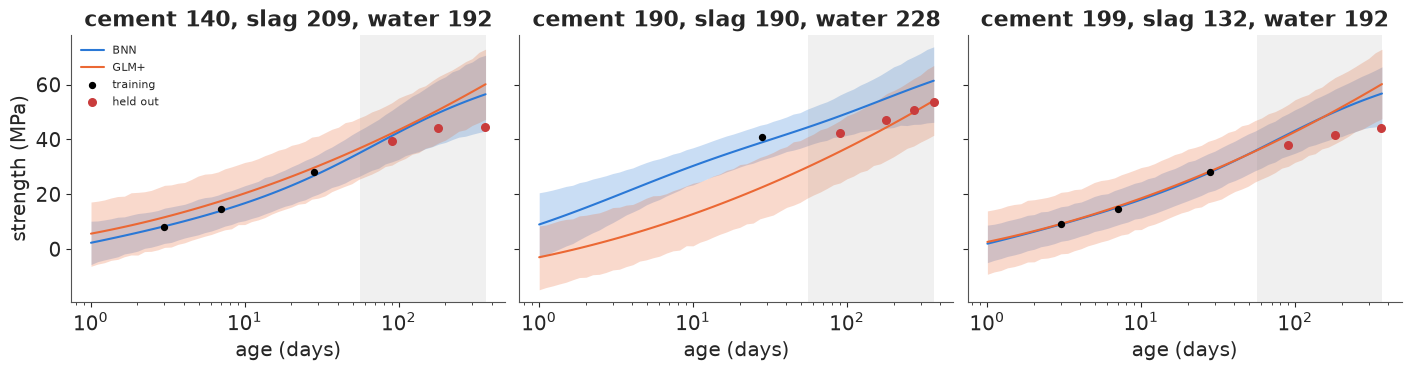

In [27]:
old = splits["old concrete"]
mix_cols = [c for c in FEATS if c != "log_age"]
mixes = concrete.groupby(mix_cols).age.agg(["min", "max", "count"])
followed = mixes[(mixes["min"] <= 28) & (mixes["max"] >= 180) & (mixes["count"] >= 4)].head(3).index
age_grid = np.linspace(0, np.log(365), 60)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, mix in zip(axes, followed):
    rows_mix = concrete[(concrete[mix_cols] == pd.Series(mix, index=mix_cols)).all(axis=1)]
    X_mix = pd.DataFrame([dict(zip(mix_cols, mix), log_age=a) for a in age_grid])[FEATS]
    X_mix = ((X_mix - old["mu"]) / old["sd"]).to_numpy()
    for label, color in [("BNN", BLUE), ("GLM+", ORANGE)]:
        mean, sd = predictors["old concrete", label](X_mix)
        y_new = mean + sd * np.random.default_rng(1).standard_normal(mean.shape)
        lo, hi = np.quantile(y_new, [0.05, 0.95], 0) * Y_SD + Y_MU
        ax.fill_between(np.exp(age_grid), lo, hi, color=color, alpha=0.25, lw=0)
        ax.plot(np.exp(age_grid), mean.mean(0) * Y_SD + Y_MU, color=color, label=label)
    seen = rows_mix.age <= 56
    ax.scatter(rows_mix.age[seen], rows_mix.strength[seen], color="k", s=18, zorder=3, label="training")
    ax.scatter(rows_mix.age[~seen], rows_mix.strength[~seen], color=RED, s=30, zorder=3, label="held out")
    ax.axvspan(56, 365, color=GREY, alpha=0.12, lw=0)
    ax.set(xscale="log", xlabel="age (days)", title=f"cement {mix[0]:.0f}, slag {mix[1]:.0f}, water {mix[3]:.0f}")
axes[0].set_ylabel("strength (MPa)")
axes[0].legend(fontsize=8);

Three mixes that were tested young (black, used for training) and old (red, held out),
with each model's 90% predictive band as a function of age. Both models predict strength
that keeps rising through a year; the measured strengths of the first and third mix level
off at about 40-45 MPa after 90 days, and both models overshoot them at 365 days - the
GLM+ more, since its quadratic in log age curves upwards, and the BNN a little less
because its tanh units start to saturate. On the middle mix the BNN is too high
throughout. Neither model can learn the plateau of cement hydration from cylinders no
older than 56 days: extrapolation is the prior's job, and neither prior knows about
hydration. What the BNN gets right is a wider band where it has no data.

Calibration of the three concrete models on both splits:

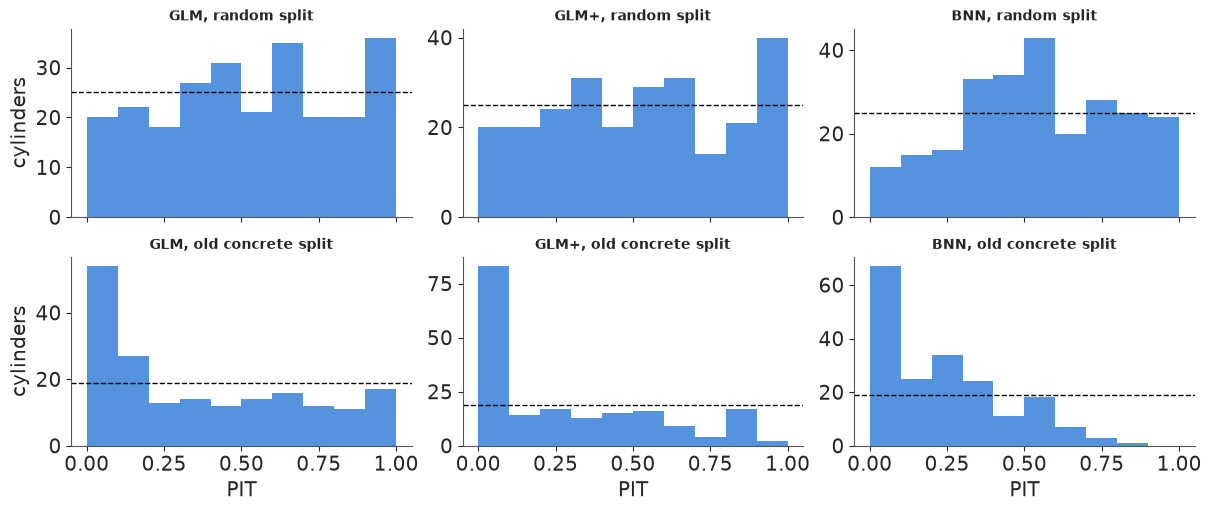

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
for row, split_name in enumerate(splits):
    for col, label in enumerate(["GLM", "GLM+", "BNN"]):
        ax = axes[row, col]
        pit = concrete_results[split_name, label]["pit"]
        ax.hist(pit, bins=np.linspace(0, 1, 11), color=BLUE, alpha=0.8)
        ax.axhline(len(pit) / 10, color="k", ls="--", lw=1)
        ax.set_title(f"{label}, {split_name} split", fontsize=10)
for ax in axes[1]:
    ax.set_xlabel("PIT")
for ax in axes[:, 0]:
    ax.set_ylabel("cylinders");

On the random split the GLMs' PITs are roughly flat - wrong mean, but a single noise sd
wide enough to cover its own errors. The BNN's pooled PIT is hump-shaped (too few values
in the outer bins): the mixture of chain-modes is a little too wide, matching its 93%
coverage. On old concrete no model is calibrated, and all three fail in the same
direction: PIT values pile up near 0, i.e. old cylinders are weaker than predicted - the
overshoot of the figure above. GLM+ fails worst. The BNN overshoots by less on average
(its lower rmse) but is no better calibrated: almost no old cylinder is in the upper third
of its predictive distribution.

## 8 · So when is a BNN worth it?

| | What we saw |
|---|---|
| One input, a smooth curve | A GP (E05) is as good, cheaper, and its hyperparameters mean something. The BNN matched it only after its priors were designed in function space. |
| Several interacting inputs, ~1000 rows | The BNN clearly beat GLMs in-distribution (rmse, lpd, interval width) and on lpd in extrapolation. That is the BNN's niche - with BART (E15) as the natural competitor. But the chains found different functional modes: what we reported was a mixture of local posteriors, and its extrapolation coverage changed from run to run. |
| Away from the data | Neither network nor GP is "honest" by default: each extrapolates its prior. tanh units flatten, a Matérn GP returns to its mean. Look at it. |
| Inference | NUTS worked on 69 parameters (and on 170, within modes) at hundreds to a thousand gradients per draw, with divergences and poorly mixing scale hyperparameters that must be reported. Function-space diagnostics are the ones that count. |
| Cheap approximations | Mean-field and full-rank ADVI and Pathfinder pruned the network and called everything noise. A MAP ensemble and a last-layer Laplace were overconfident. On small data, the full posterior is what made the network work. |
| Weights | Never interpretable one by one; ARD scales measure non-linearity, not importance. |

The posterior over weights buys **calibrated function-space uncertainty on small data,
for a model flexible enough to find interactions you did not specify**. It costs a
thousand gradients per draw, a prior that has to be designed by looking at functions, and
diagnostics in function space. On a large data set, where a MAP network is already
well-determined and NUTS is unaffordable, the cheaper methods become reasonable - but on
data this size, the approximations failed badly enough that "a BNN" fitted with them is
closer to a GLM with noise or to an overfit network than to a Bayesian model.

## Try it yourself

1. **ReLU instead of tanh.** Replace `pt.tanh` with `pt.maximum(0, .)` in the motorcycle
   network (and in `forward`). Redo the prior-function plots of section 3, refit with NUTS,
   and compare the behaviour past 58 ms with the tanh network and the GP. What does a ReLU
   network predict for concrete at 365 days?
2. **Modes and stacking.** Refit the concrete BNN with 8 chains (nutpie runs them as
   threads) and with a single input scale shared by all features. How many distinct
   functional modes do you find (per-chain lpd and predictions)? Weight the chains by
   stacking their held-out predictive densities (`scipy.optimize` on the simplex, or
   `az.compare` on per-chain LOO) and compare with equal weights.
3. **Classification.** Fit a BNN with a Bernoulli likelihood to the `wells` data of E03
   (switch or not, from arsenic, distance, association and education). Compare held-out
   lpd and a calibration plot (`az.plot_ppc_pava`, or binned predicted vs observed rates)
   with E03's best logistic regression. Is there any non-linearity left for the network to
   find?